# Breast Cancer Diagnosis Pipeline (CBIS-DDSM)

## 1. Introduction and Problem Statement
This notebook presents a complete end-to-end Machine Learning pipeline for the classification of breast masses in digital mammography. The primary objective is to automatically distinguish between **Benign** and **Malignant** lesions using the **CBIS-DDSM** (Curated Breast Imaging Subset of DDSM) dataset.

The project focuses on analyzing tabular data extracted from lesion masks (ROI - Region of Interest) combined with clinical metadata.

## 2. Methodology and Approach
The experiment compares the performance of ML models across three distinct feature sets (Feature Vectors) to determine the impact of integrating clinical knowledge with automated geometric analysis:

1.  **Shape-Only (Geometric):** Morphological descriptors calculated directly from segmentation masks.
2.  **BI-RADS-Only (Clinical):** Utilizing only the standardized radiological assessment score (BI-RADS) as a predictive feature.
3.  **Hybrid (Combined):** A fusion of quantitative shape descriptors and expert radiological knowledge (BI-RADS).

## 3. Pipeline Structure
The workflow is strictly designed to prevent data leakage and ensure robust evaluation:

* **Preprocessing:** Data cleaning, target mapping (Benign/Malignant $\to$ 0/1), and feature normalization (`StandardScaler`).
* **Patient-Aware Split:** Implementation of a custom split strategy ensuring that all images belonging to the same patient remain in the same subset (Train or Test) to prevent **Patient Leakage**.
* **Hyperparameter Tuning:** Automated parameter optimization using `GridSearchCV` (with internal cross-validation) for Random Forest, SVM, Logistic Regression, and KNN.
* **Evaluation:** Final model assessment using **Stratified 5-Fold Cross-Validation** on the test set, reporting metrics such as ROC AUC, Accuracy, Precision, Recall, and F1-Score.

---
## Setup and Library Imports
This section initializes the environment by importing essential libraries for data manipulation, visualization, and the machine learning workflow.

Key components include:
* **Core Data Stack:** `pandas` and `numpy` for data structure manipulation.
* **Scikit-Learn Ecosystem:**
    * **Models:** Random Forest, SVM (RBF), Logistic Regression, and KNN.
    * **Optimization:** `GridSearchCV` for hyperparameter tuning and `StratifiedKFold` for robust cross-validation.
    * **Preprocessing:** `StandardScaler` for feature normalization.
* **Custom Modules:** Imports from the `src` package handling specific logic for data splitting and evaluation.

In [24]:
# Core
import os
import json
import pandas as pd
import numpy as np

# Stratified Sampling and Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import roc_auc_score

# Machine Learning Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Feature scaler
from sklearn.preprocessing import StandardScaler

# Modules from src directory
from preprocessing_mask_segmentation import preprocessing as pre
from shape_features import shape_features as sf
from pyrandomics_playground import pyrandomics_implementation as pr
from split import split
from feature_engineering import selection as sel
from evaluation import model_eval
from resize_image import resize as res

# Visualisation
# import matplotlib.pyplot as plt
# import seaborn as sns

---
## File Paths and Global Configuration
This section establishes the file system structure for inputs (images, labels) and outputs (processed features, split datasets, evaluation plots).

**Configuration Management (`config.json`):**
The pipeline's workflow is dynamically controlled by the external `config.json` file. This acts as a **central control unit**, allowing users to modify execution logic (e.g., enabling Hyperparameter Tuning, selecting Data Split strategy, or toggling Feature Extraction) without altering the source code.

In [25]:
IMAGES_PATH = "../images/"
CONFIG_JSON_PATH = "config.json"

CSV_PATH = "../labels.csv"
MERGED_CSV_AND_FEATURE_PATH = "../output/features.csv"
ASSESSMENT_ONLY_PATH = "../output/assessment_only_vector.csv"

PLOT_PATH = "../output/performance_comparison.png"

X_TRAIN_PATH = "../output/X_train.csv"
X_TEST_PATH = "../output/X_test.csv"
Y_TRAIN_PATH = "../output/y_train.csv"
Y_TEST_PATH = "../output/y_test.csv"

X_TRAIN_HYBRID = "../output/X_train_hybrid.csv"
X_TEST_HYBRID = "../output/X_test_hybrid.csv"
Y_TRAIN_HYBRID = "../output/y_train_hybrid.csv"
Y_TEST_HYBRID = "../output/y_test_hybrid.csv"

X_TRAIN_ASSESSMENT_ONLY_PATH = "../output/x_train_assessment_only.csv"
X_TEST_ASSESSMENT_ONLY_PATH = "../output/x_test_assessment_only.csv"
Y_TRAIN_ASSESSMENT_ONLY_PATH = "../output/y_train_assessment_only.csv"
Y_TEST_ASSESSMENT_ONLY_PATH = "../output/y_test_assessment_only.csv"

In [26]:
# Import configuration file
with open(CONFIG_JSON_PATH) as f:
    config = json.load(f)

## Image Preprocessing and Feature Extraction
This section transforms raw segmentation masks into a structured tabular dataset ready for machine learning. The execution flow is controlled by the `import_features_instead_of_training` flag in `config.json`.

**Workflow:**
1.  **Image Loading & Cleaning:** Reads mask images and applies noise removal (`clean_mask`).
2.  **Feature Engineering:** Extracts quantitative descriptors using two methods:
    * **Geometric Features:** Basic shape descriptors (Area, Perimeter, etc.) via `regionprops`.
    * **Radiomic Features:** Shape analytics via the `PyRadiomics` library.
3.  **Data Integration:** Merges extracted features with patient metadata (`labels.csv`) based on a unique ID.
4.  **Target Encoding:** Maps the diagnostic string to a binary target variable (`MALIGNANT` $\to$ 1, `BENIGN` $\to$ 0).

In [27]:
if not config['import_features_instead_of_training']:
    images_names = sorted([f for f in os.listdir(IMAGES_PATH) if f.endswith('.png')])

    # Import and preprocess images
    images_dict = {}
    for image_name in images_names:
        full_path = os.path.join(IMAGES_PATH, image_name)
        key = image_name.split('.')[0]
        img = pre.clean_mask(full_path)

        if config['resize_images']:
            # Image Resizing - only if CNN is used
            img = res.resize_with_padding(img)
            img = np.array(img)
        images_dict[key] = img

    # Extract features from images
    features_results = []

    for name, img in images_dict.items():
        full_path = os.path.join(IMAGES_PATH, name + ".png")
        features = sf.extract_shape_features(img)  # Extract features using region props based module
        pr_features = pr.extract_shape_features_from_mask(full_path)  # Extract features using pyradiomics based module
        features.update(pr_features)  # Update features dictionary with pyradiomics features
        if features:
            features['id'] = name
            features_results.append(features)
        else:
            print(f"{name} omitted (empty mask or unexpected error).")

    # Convert features_results into Pandas DataFrame
    df_feature_results = pd.DataFrame(features_results)

    # Import CSV file and
    csv_file = pd.read_csv(CSV_PATH)

    # Convert id columns to string to prepare merge
    csv_file['id'] = csv_file['id'].astype(str)
    df_feature_results["id"] = df_feature_results["id"].astype(str)

    # Merge CSV columns and feature DataFrame into one final DataFrame
    df_features = pd.merge(csv_file, df_feature_results, left_on='id', right_on='id')

    # Drop useless columns and convert target feature into binary value
    df_features.drop(columns='abnormality_type', inplace=True)
    mapping = {'MALIGNANT': 1, 'BENIGN': 0}
    df_features['pathology'] = df_features['pathology'].map(mapping)
else:
    df_features = pd.read_csv(MERGED_CSV_AND_FEATURE_PATH)

In [28]:
# Drop rows with BI-RADS assessment not included in config.json file
df_features = df_features[df_features['assessment'].isin(config['selected_assessments'])]

assessment_remaining_cols = ['id', 'patient_id', 'pathology', 'assessment']
df_assessment_only = df_features[assessment_remaining_cols]

# Export final DataFrame into CSV file
df_features.to_csv(MERGED_CSV_AND_FEATURE_PATH, index=False)
df_assessment_only.to_csv(ASSESSMENT_ONLY_PATH, index=False)

---
## Test of Feature Extraction and Preprocessing
This section validates the preprocessing results by displaying the generated feature vectors and their statistical summaries to ensure data integrity before modeling.

In [29]:
df_features

,id,patient_id,assessment,pathology,Area,Area Bounding Box,Area Convex,Area Filled,Axis Major Length,Axis Minor Length,...,Hu Moment 7,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity
0,1001,P_00001,4,1,120176.0,184775.0,144592.0,120176.0,437.817532,369.842129,...,41.605810,0.840962,447.005783,502.236996,124054.0,375.915034,11341.453814,0.091424,124881.0,0.110088
1,1002,P_00001,4,1,32114.0,54432.0,39160.0,32114.0,215.156997,204.049262,...,35.156400,0.943530,221.291459,262.937255,33513.0,208.795081,4451.100356,0.132817,33875.0,0.145796
2,1003,P_00004,4,0,113057.0,162306.0,132259.0,113057.0,403.087349,373.343420,...,-39.577490,0.925515,409.909988,452.659916,116337.0,379.377683,10081.557277,0.086658,117128.0,0.119932
3,1004,P_00004,4,0,89182.0,147452.0,111392.0,89182.0,361.346738,333.637192,...,-39.404040,0.923041,369.899218,429.382114,92938.0,341.432140,11268.303669,0.121245,93806.0,0.095905
4,1005,P_00004,4,0,91546.0,151434.0,108858.0,91546.0,389.640992,311.266317,...,38.290290,0.801773,396.665021,441.897047,94536.0,318.035325,9069.472791,0.095937,95248.0,0.120177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,2660,P_01825,3,0,27042.0,44522.0,33279.0,27042.0,225.676587,163.949792,...,-34.753800,0.738651,231.590498,264.151472,28669.0,171.064565,4935.097398,0.172141,29063.0,0.121623
1660,2661,P_01833,5,1,168417.0,231632.0,179350.0,168417.0,495.387348,442.668797,...,-41.506033,0.894221,500.356603,532.379564,171250.0,447.429134,8814.252445,0.051470,171959.0,0.166431
1661,2662,P_01865,4,1,28723.0,50935.0,40694.0,28723.0,317.452191,141.700567,...,36.442295,0.452301,323.419774,330.492057,30312.0,146.283225,4707.627268,0.155306,30656.0,0.131102
1662,2663,P_01912,5,1,96990.0,149408.0,112074.0,96990.0,387.619283,329.299319,...,-38.783403,0.849831,394.723599,434.885042,99995.0,335.448353,8754.813844,0.087553,100659.0,0.128040


In [30]:
df_features.describe()

,assessment,pathology,Area,Area Bounding Box,Area Convex,Area Filled,Axis Major Length,Axis Minor Length,Centroid X,Centroid Y,...,Hu Moment 7,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity
count,1664.000000,1664.000000,1.664000e+03,1.664000e+03,1.664000e+03,1.664000e+03,1664.000000,1664.000000,1664.000000,1664.000000,...,1664.000000,1664.000000,1664.000000,1664.000000,1.664000e+03,1664.000000,1664.000000,1664.000000,1.664000e+03,1664.000000
mean,3.501202,0.458534,7.868357e+04,1.221009e+05,9.073593e+04,7.868357e+04,334.169193,269.915583,206.031864,202.283244,...,0.093411,0.815981,339.966279,373.587871,8.088757e+04,275.892554,6771.636978,0.109066,8.141759e+04,0.144375
std,1.404828,0.498427,8.055054e+04,1.206283e+05,9.094821e+04,8.055054e+04,137.835099,113.287892,83.124890,81.275151,...,37.016106,0.105319,137.912696,146.274700,8.145605e+04,113.350225,3408.396570,0.040458,8.167956e+04,0.030806
min,0.000000,0.000000,3.966000e+03,6.095000e+03,4.643000e+03,3.966000e+03,80.596272,52.545921,51.516357,53.855270,...,-47.280762,0.235148,85.949642,99.764723,4.462000e+03,56.021813,1176.302741,0.012086,4.588000e+03,0.078946
25%,3.000000,0.000000,3.621375e+04,5.792400e+04,4.223800e+04,3.621375e+04,245.383208,195.395222,152.343274,148.652792,...,-36.714913,0.759485,251.109973,279.028672,3.776600e+04,201.410715,4662.178567,0.082740,3.813025e+04,0.126931
50%,4.000000,0.000000,5.651000e+04,8.885800e+04,6.547500e+04,5.651000e+04,305.682136,247.529924,188.373131,186.009010,...,26.018202,0.832634,311.029433,342.118299,5.848175e+04,253.375901,6003.902664,0.103361,5.902050e+04,0.140712
75%,4.000000,1.000000,9.042775e+04,1.425425e+05,1.045720e+05,9.042775e+04,383.560436,318.783599,237.281471,236.437932,...,36.752786,0.892520,389.353409,428.077388,9.278538e+04,325.452030,7872.580692,0.130612,9.339600e+04,0.155642
max,5.000000,1.000000,1.251936e+06,1.797881e+06,1.345671e+06,1.251936e+06,1317.697863,1222.367729,811.905826,791.568087,...,49.230771,0.991157,1325.946937,1380.488682,1.266556e+06,1230.996844,35311.304151,0.342320,1.269045e+06,0.469933


In [31]:
df_assessment_only

,id,patient_id,pathology,assessment
0,1001,P_00001,1,4
1,1002,P_00001,1,4
2,1003,P_00004,0,4
3,1004,P_00004,0,4
4,1005,P_00004,0,4
...,...,...,...,...
1659,2660,P_01825,0,3
1660,2661,P_01833,1,5
1661,2662,P_01865,1,4
1662,2663,P_01912,1,5


In [32]:
df_assessment_only.describe()

,pathology,assessment
count,1664.000000,1664.000000
mean,0.458534,3.501202
std,0.498427,1.404828
min,0.000000,0.000000
25%,0.000000,3.000000
50%,0.000000,4.000000
75%,1.000000,4.000000
max,1.000000,5.000000


---
## Select Features

This module optimizes the feature space by eliminating redundant and non-robust descriptors to prevent multicollinearity and overfitting.

**Key Operations:**
1.  **Correlation Filtering:** Automated removal of features with a high Pearson correlation coefficient. If two features are strongly correlated (providing identical information), one is dropped to simplify the model. Critical metadata (e.g., `patient_id`, `pathology`) is protected from this process.
2.  **Scale & Rotation Invariance:** Manual removal of scale-dependent features like `Area` (raw pixel count) and `Orientation`. This ensures the model relies on relative morphology (e.g., `Relative Area`, `Compactness`) rather than image resolution or rotation.

In [50]:
metadata_cols = ['id', 'patient_id', 'pathology', 'assessment', "Relative Area"]
df_dropped_cols = sel.drop_high_correlation_features(df_features, exclude=metadata_cols)

df_cleaned = df_dropped_cols[0]
dropped_features = df_dropped_cols[1]

# Drop remaining scale dependent features
remaining_scale_dependent_features = ["Area", "Orientation"]
df_cleaned = df_cleaned.drop(columns=remaining_scale_dependent_features)

Dropped 27 redundant features due to high correlation (> 0.9): ['Area Bounding Box', 'Area Convex', 'Area Filled', 'Axis Major Length', 'Axis Minor Length', 'Centroid X', 'Centroid Y', 'Equivalent Diameter', 'Feret Diameter Max', 'Perimeter', 'Aspect Ratio', 'Convexity', 'Irregularity Index', 'Roundness', 'Shape Factor', 'Hu Moment 1', 'Hu Moment 2', 'Hu Moment 3', 'original_shape2D_Elongation', 'original_shape2D_MajorAxisLength', 'original_shape2D_MaximumDiameter', 'original_shape2D_MeshSurface', 'original_shape2D_MinorAxisLength', 'original_shape2D_Perimeter', 'original_shape2D_PerimeterSurfaceRatio', 'original_shape2D_PixelSurface', 'original_shape2D_Sphericity']


---
## Patient-Aware Train/Test Split
This module performs the critical task of partitioning the dataset into Training and Test subsets. Unlike standard random splitting, this process is **Patient-Aware**, grouping samples strictly by `patient_id`.

**Why is this crucial?**
In medical datasets (like CBIS-DDSM), a single patient often contributes multiple images. A naive random split could place one image of Patient A in the Training set and another image of Patient A in the Test set. This would cause **Data Leakage**, allowing the model to "memorize" the patient's anatomy rather than learning general cancer features.

**Features:**
* **Leakage Prevention:** Ensures complete isolation of patients between sets.
* **Configurable Strategy:** The `use_classic_aware_split` flag selects between a standard group split or a Stratified Group split (which tries to maintain class balance).
* **Multiple Vectors:** The split is applied consistently across all feature sets (Shape-Only, Hybrid, and Assessment-Only).
* **Verification:** An automated check confirms that the intersection of Patient IDs between Train and Test sets is empty.

In [34]:
drop_cols = ['id', 'patient_id', 'pathology', 'assessment']
drop_cols_without_assessment = ['id', 'patient_id', 'pathology']

# Choose 1. or 2. split function - classic or stratified_kfold-based

if config['use_classic_aware_split'] == 1:
    # 1. classic function
    X_train, X_test, y_train, y_test, is_intersect_empty = split.aware_patient_split(df_cleaned, drop_cols)

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid, is_intersect_empty_hybrid = split.aware_patient_split(
        df_cleaned, drop_cols_without_assessment)

    X_train_assessment_only, X_test_assessment_only, y_train_assessment_only, y_test_assessment_only, is_intersect_empty_assessment_only = split.aware_patient_split(
        df_assessment_only, drop_cols_without_assessment)
else:
    # 2. stratified_kfold-based function
    X_train, X_test, y_train, y_test, is_intersect_empty = split.aware_patient_split_stratified_kfold(df_cleaned,
                                                                                                      drop_cols)

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid, is_intersect_empty_hybrid = split.aware_patient_split_stratified_kfold(
        df_cleaned, drop_cols_without_assessment)

    X_train_assessment_only, X_test_assessment_only, y_train_assessment_only, y_test_assessment_only, is_intersect_empty_assessment_only = split.aware_patient_split_stratified_kfold(
        df_assessment_only, drop_cols_without_assessment)

# Verify that the intersection of patient IDs in Train and Test sets is empty
print(is_intersect_empty)
print(is_intersect_empty_hybrid)
print(is_intersect_empty_assessment_only)

True
True
True


## Vectors Before Features Scaling

In [35]:
X_train

,Eccentricity,Extent,Solidity,Circularity,Relative Area,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,0.535176,0.650391,0.831139,0.214861,0.408762,-20.574172,-41.554963,-29.188242,41.605810
1,0.317155,0.589984,0.820072,0.321471,0.377776,-17.634853,-35.211028,-24.604329,35.156400
7,0.477649,0.704325,0.898705,0.461747,0.461027,-16.157593,-32.799962,23.026264,-33.301411
8,0.614588,0.661231,0.907256,0.480872,0.420450,-18.774203,-38.087259,-26.467408,-38.409530
9,0.448610,0.626952,0.883886,0.366522,0.414699,-15.579505,32.728438,23.038421,-32.243538
...,...,...,...,...,...,...,...,...,...
1659,0.687186,0.607385,0.812585,0.257870,0.377260,-17.034603,34.782807,24.588699,-34.753800
1660,0.448902,0.727089,0.939041,0.512764,0.484174,-20.450785,41.790010,29.009514,-41.506033
1661,0.894849,0.563915,0.705829,0.236020,0.318296,-18.441229,-37.372978,-26.574930,36.442295
1662,0.527519,0.649162,0.865410,0.271296,0.421227,-18.894161,-37.902603,-27.233321,-38.783403


In [36]:
X_train_hybrid

,assessment,Eccentricity,Extent,Solidity,Circularity,Relative Area,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,4,0.535176,0.650391,0.831139,0.214861,0.408762,-20.574172,-41.554963,-29.188242,41.605810
1,4,0.317155,0.589984,0.820072,0.321471,0.377776,-17.634853,-35.211028,-24.604329,35.156400
7,4,0.477649,0.704325,0.898705,0.461747,0.461027,-16.157593,-32.799962,23.026264,-33.301411
8,4,0.614588,0.661231,0.907256,0.480872,0.420450,-18.774203,-38.087259,-26.467408,-38.409530
9,4,0.448610,0.626952,0.883886,0.366522,0.414699,-15.579505,32.728438,23.038421,-32.243538
...,...,...,...,...,...,...,...,...,...,...
1659,3,0.687186,0.607385,0.812585,0.257870,0.377260,-17.034603,34.782807,24.588699,-34.753800
1660,5,0.448902,0.727089,0.939041,0.512764,0.484174,-20.450785,41.790010,29.009514,-41.506033
1661,4,0.894849,0.563915,0.705829,0.236020,0.318296,-18.441229,-37.372978,-26.574930,36.442295
1662,5,0.527519,0.649162,0.865410,0.271296,0.421227,-18.894161,-37.902603,-27.233321,-38.783403


In [37]:
X_train_assessment_only

,assessment
0,4
1,4
7,4
8,4
9,4
...,...
1659,3
1660,5
1661,4
1662,5


## Scale Features with StandardScaler

In [38]:
# Scale standard feature vector
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Scale hybrid vector
scaler_hybrid = StandardScaler()
X_train_hybrid_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_hybrid),
    columns=X_train_hybrid.columns,
    index=X_train_hybrid.index
)
X_test_hybrid_scaled = pd.DataFrame(
    scaler.transform(X_test_hybrid),
    columns=X_test_hybrid.columns,
    index=X_test_hybrid.index
)

# Scale assessment-only vector
scaler_assessment_only = StandardScaler()
X_train_assessment_only_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_assessment_only),
    columns=X_train_assessment_only.columns,
    index=X_train_assessment_only.index
)
X_test_assessment_only_scaled = pd.DataFrame(
    scaler.transform(X_test_assessment_only),
    columns=X_test_assessment_only.columns,
    index=X_test_assessment_only.index
)

# Export X_train_scaled, X_test_scaled, y_train, y_test into CSV file
X_train_scaled.to_csv(X_TRAIN_PATH, index=False)
X_test_scaled.to_csv(X_TEST_PATH, index=False)
y_train.to_csv(Y_TRAIN_PATH, index=False)
y_test.to_csv(Y_TEST_PATH, index=False)

# Export X_train_hybrid_scaled, X_test_hybrid_scaled, y_train_hybrid, y_test_hybrid into CSV file
X_train_hybrid_scaled.to_csv(X_TRAIN_HYBRID, index=False)
X_test_hybrid_scaled.to_csv(X_TEST_HYBRID, index=False)
y_train_hybrid.to_csv(Y_TRAIN_HYBRID, index=False)
y_test_hybrid.to_csv(Y_TEST_HYBRID, index=False)

# Export X_train_assessment_only_scaled, X_test_assessment_only_scaled , y_train_assessment_only, y_test_assessment_only into CSV file
X_train_assessment_only.to_csv(X_TRAIN_ASSESSMENT_ONLY_PATH, index=False)
X_test_assessment_only.to_csv(X_TEST_ASSESSMENT_ONLY_PATH, index=False)
y_train_assessment_only.to_csv(Y_TRAIN_ASSESSMENT_ONLY_PATH, index=False)
y_test_assessment_only.to_csv(Y_TEST_ASSESSMENT_ONLY_PATH, index=False)

---
## Validate Features Scaling
This section validates the scaling results by displaying the generated scaled feature vectors and their statistical summaries to ensure data integrity before modeling.

In [49]:
print(X_train_scaled.describe())

       Eccentricity        Extent      Solidity   Circularity  Relative Area  \
count  1.334000e+03  1.334000e+03  1.334000e+03  1.334000e+03   1.334000e+03   
mean  -5.512832e-16  5.006823e-16  2.261060e-15 -1.278338e-16   1.411498e-15   
std    1.000375e+00  1.000375e+00  1.000375e+00  1.000375e+00   1.000375e+00   
min   -3.031034e+00 -3.667965e+00 -4.221920e+00 -2.172167e+00  -3.458828e+00   
25%   -6.789869e-01 -6.462127e-01 -6.412553e-01 -6.957391e-01  -6.540081e-01   
50%    3.393877e-02  1.782241e-02  4.616368e-02 -1.575584e-01   2.187748e-02   
75%    6.933861e-01  6.247528e-01  6.537425e-01  5.125517e-01   6.369648e-01   
max    2.847676e+00  4.957239e+00  2.631270e+00  5.030946e+00   4.932298e+00   

        Hu Moment 4   Hu Moment 5   Hu Moment 6   Hu Moment 7  
count  1.334000e+03  1.334000e+03  1.334000e+03  1.334000e+03  
mean   1.709777e-15  2.130563e-17  5.859048e-17  5.060087e-17  
std    1.000375e+00  1.000375e+00  1.000375e+00  1.000375e+00  
min   -3.711911e+00 -1.

In [40]:
X_train_hybrid_scaled

,assessment,Eccentricity,Extent,Solidity,Circularity,Relative Area,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,0.355686,-0.121013,0.192555,-0.611440,-1.246746,0.057009,-1.467629,-0.994531,-0.995914,1.116544
1,0.355686,-1.594384,-0.776327,-0.829453,-0.313038,-0.642569,0.351609,-0.821938,-0.818123,0.942475
7,0.355686,-0.509777,1.057614,0.719556,0.915518,1.237030,1.265933,-0.756343,1.029270,-0.905199
8,0.355686,0.415641,0.366418,0.887998,1.083020,0.320901,-0.353571,-0.900189,-0.890384,-1.043067
9,0.355686,-0.706022,-0.183383,0.427638,0.081524,0.191052,1.623729,1.026418,1.029742,-0.876647
...,...,...,...,...,...,...,...,...,...,...
1659,-0.365416,0.906257,-0.497224,-0.976940,-0.870066,-0.654223,0.723123,1.082309,1.089871,-0.944399
1660,1.076789,-0.704049,1.422723,1.514142,1.362335,1.759620,-1.391261,1.272946,1.261336,-1.126642
1661,0.355686,2.309624,-1.194453,-3.079933,-1.061428,-1.985488,-0.147483,-0.880756,-0.894554,0.977181
1662,1.076789,-0.172760,0.172843,0.063683,-0.752484,0.338434,-0.427816,-0.895165,-0.920090,-1.053158


In [41]:
X_train_assessment_only_scaled

,assessment
0,0.355686
1,0.355686
7,0.355686
8,0.355686
9,0.355686
...,...
1659,-0.365416
1660,1.076789
1661,0.355686
1662,1.076789


---
## Model Initialization and Experiment Configuration
This section defines the core components of the experimental framework:

1.  **Classifiers:** Initialization of four distinct machine learning algorithms (Logistic Regression, SVM, Random Forest, kNN).
2.  **Evaluation Metrics:** Definition of the scoring dictionary (Accuracy, Precision, Recall, F1-Score, ROC AUC).
3.  **Experiment Vectors:** Organization of the three feature sets (Shape-Only, BI-RADS, Hybrid) into a structured list containing their respective Train/Test arrays.

In [42]:
models_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

vectors = [
    {
        'config_key': 'shape_only',
        'name': 'Shape-Only',
        'X_train': X_train_scaled,
        'y_train': y_train,
        'X_test': X_test_scaled,
        'y_test': y_test
    },
    {
        'config_key': 'assessment_only',
        'name': 'BI-RADS-Score-Only',
        'X_train': X_train_assessment_only_scaled,
        'y_train': y_train_assessment_only,
        'X_test': X_test_assessment_only_scaled,
        'y_test': y_test_assessment_only
    },
    {
        'config_key': 'hybrid',
        'name': 'Hybrid (Shape + BI-RADS Score)',
        'X_train': X_train_hybrid_scaled,
        'y_train': y_train_hybrid,
        'X_test': X_test_hybrid_scaled,
        'y_test': y_test_hybrid
    }
]

# Filter out vectors list: include dictionaries with config_key in "train_and_evaluate" config.json section
vectors = [v for v in vectors if v['config_key'] in config['train_and_evaluate']]
for v in vectors:
    print(f'{v["name"]} vector selected for testing')

Shape-Only vector selected for testing
BI-RADS-Score-Only vector selected for testing
Hybrid (Shape + BI-RADS Score) vector selected for testing


---
## Hyperparameter Optimization (GridSearchCV)
This module performs automated hyperparameter tuning to maximize model performance. The execution is conditional, controlled by the `perform_hyperparameter_tuning` flag in `config.json`.

**Methodology:**
* **Search Strategy:** GridSearchCV over defined parameter spaces for Random Forest, SVM, Logistic Regression, and kNN.
* **Validation:** Uses **Stratified 5-Fold Cross-Validation** strictly on the **Training Set** to find optimal parameters. The Test Set is reserved for final evaluation only, ensuring no data leakage occurs during tuning.
* **Optimization Target:** Models are tuned to maximize the **ROC AUC** score.

In [43]:
# Dictionary to store the best model instances for each vector
# Structure: { 'Shape-Only': {'Random Forest': best_rf_model, ...}, ... }
best_models_per_vector = {}

if config['perform_hyperparameter_tuning']:
    optimization_configs = {
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "params": {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
            }
        },
        "SVM (RBF)": {
            "model": SVC(probability=True, random_state=42, class_weight='balanced'),
            "params": {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 0.1, 0.01],
                'kernel': ['rbf']
            }
        },
        "Logistic Regression": {
            "model": LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear'),
            "params": {
                'C': [0.01, 0.1, 1, 10, 100],  # Lower C - stronger regularization
                'penalty': ['l1', 'l2']
                #L1 - remove useless shape descriptors by zeroing their weights, l2 - penalize large weights but does not force them to zero
            }
        },
        "KNN": {
            "model": KNeighborsClassifier(),
            "params": {
                'n_neighbors': [3, 5, 7, 9, 11],  # Odd number of neighbours to avoid draw
                'weights': ['uniform', 'distance'],  # Distance: closer neighbour's vote is more important
                'metric': ['euclidean', 'manhattan']  # Select default metric
            }
        }
    }

    # Containers for results
    tuning_results_data = []

    # Use the same CV strategy as in the rest of the project
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Loop through Feature Vectors (Shape, BI-RADS, Hybrid)
    for vector in vectors:
        vec_name = vector['name']
        X_train_curr = vector['X_train']
        y_train_curr = vector['y_train']

        # Validation set (Just for a quick check, not used for tuning!)
        X_test_curr = vector['X_test']
        y_test_curr = vector['y_test']

        print(f"{'-' * 60}")
        print(f" TUNING FOR VECTOR: {vec_name}")
        print(f"{'-' * 60}")

        best_models_per_vector[vec_name] = {}

        # Loop through Models defined in configuration
        for model_name, opt_config in optimization_configs.items():
            print(f"Optimizing: {model_name}...")

            # GridSearchCV performs internal Cross-Validation to find best params
            grid_search = GridSearchCV(
                estimator=opt_config["model"],
                param_grid=opt_config["params"],
                cv=cv,
                scoring='roc_auc',  # Optimizing for ROC AUC
                n_jobs=-1,  # Use all available CPU cores
                verbose=1  # Show progress
            )

            # Fit GridSearch on the Training Data
            grid_search.fit(X_train_curr, y_train_curr)

            # Save the best estimator found
            best_model = grid_search.best_estimator_
            best_models_per_vector[vec_name][model_name] = best_model

            # Quick validation on the test set (for information only)
            # Note: GridSearch optimized on X_train
            y_prob = best_model.predict_proba(X_test_curr)[:, 1]
            auc_score = roc_auc_score(y_test_curr, y_prob)

            print(f"Best Params: {grid_search.best_params_}")
            print(f"Best CV Score (Train): {grid_search.best_score_:.4f}")
            print(f"Test ROC AUC: {auc_score:.4f}")

            tuning_results_data.append({
                "Vector": vec_name,
                "Model": model_name,
                "Best Params": str(grid_search.best_params_),
                "Best CV Score (Train)": grid_search.best_score_,
                "Test AUC": auc_score
            })

    # Display Summary
    tuning_df = pd.DataFrame(tuning_results_data)
    # If using Jupyter, use display(), otherwise print()
    try:
        display(tuning_df)
    except NameError:
        print(tuning_df)
else:
    print(f"{'-' * 60}")
    print("HYPERPARAMETER TUNING (SKIPPED via config)")
    print("Using default model parameters for Cross-Validation.")
    print(f"{'-' * 60}")

------------------------------------------------------------
 TUNING FOR VECTOR: Shape-Only
------------------------------------------------------------
Optimizing: Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score (Train): 0.6037
Test ROC AUC: 0.5628
Optimizing: SVM (RBF)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score (Train): 0.6077
Test ROC AUC: 0.5469
Optimizing: Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 1, 'penalty': 'l2'}
Best CV Score (Train): 0.6137
Test ROC AUC: 0.5893
Optimizing: KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV Score (Train): 0.5802
Test ROC AUC: 0.5316
--------------------

,Vector,Model,Best Params,Best CV Score (Train),Test AUC
0,Shape-Only,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.603713,0.562755
1,Shape-Only,SVM (RBF),"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.607718,0.546869
2,Shape-Only,Logistic Regression,"{'C': 1, 'penalty': 'l2'}",0.613701,0.589264
3,Shape-Only,KNN,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.580175,0.531571
4,BI-RADS-Score-Only,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.835333,0.875483
5,BI-RADS-Score-Only,SVM (RBF),"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.832424,0.881411
6,BI-RADS-Score-Only,Logistic Regression,"{'C': 0.01, 'penalty': 'l1'}",0.828880,0.875005
7,BI-RADS-Score-Only,KNN,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.833278,0.876845
8,Hybrid (Shape + BI-RADS Score),Random Forest,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.841998,0.864843
9,Hybrid (Shape + BI-RADS Score),SVM (RBF),"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",0.837237,0.875704


---
## Stratified Cross-Validation
This section performs the primary performance estimation of the candidate models. To handle class imbalance, **Stratified 5-Fold Cross-Validation** is applied.

**Key Logic:**
* **Adaptive Selection:** The pipeline automatically detects if a **Tuned Model** was found in the previous step. If yes, it evaluates the optimized version; otherwise, it falls back to the **Default Model** configuration.
* **Comprehensive Scoring:** Accuracy, Precision, Recall, F1, ROC AUC are calculated for every fold to capture the trade-off between sensitivity and specificity.
* **Result Aggregation:** The Mean and Standard Deviation of these scores are recorded to assess model stability.

In [44]:
cv_results_data = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for vector in vectors:
    vec_name = vector['name']
    X_train_curr = vector['X_train']
    y_train_curr = vector['y_train']

    print(f"{'-' * 60}")
    print(f"Processing Vector: {vec_name}")
    print(f"{'-' * 60}")

    for model_name, default_model in models_list.items():
        if vec_name in best_models_per_vector and model_name in best_models_per_vector[vec_name]:
            model_to_use = best_models_per_vector[vec_name][model_name]
        else:
            # Hyperparameter tuning skipped or best_best_models_per_vector is empty
            # Use default model
            model_to_use = default_model
        try:
            cv_scores = cross_validate(
                model_to_use,
                X_train_curr,
                y_train_curr,
                cv=cv,
                scoring=scoring,
                n_jobs=-1
            )

            for metric in scoring.keys():
                key = f"test_{metric}"

                if key in cv_scores:
                    mean_val = np.mean(cv_scores[key])
                    std_val = np.std(cv_scores[key])

                    cv_results_data.append({
                        "Vector name: ": vec_name,
                        "Model": model_name,
                        "Metric": metric,
                        "Mean": mean_val,
                        "Std": std_val
                    })

            print(f"{model_name}: OK")

        except Exception as e:
            print(f"{model_name}: Error - {str(e)}")

------------------------------------------------------------
Processing Vector: Shape-Only
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK
------------------------------------------------------------
Processing Vector: BI-RADS-Score-Only
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK
------------------------------------------------------------
Processing Vector: Hybrid (Shape + BI-RADS Score)
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK


---
## Model Evaluation and Analysis
This module synthesizes the results from the cross-validation stage to identify and analyze the optimal solution.

**Key Components:**
* **Comparative Visualization:** Generation of boxplots to visually compare the distribution of performance metrics (ROC AUC, Accuracy) across all models and feature vectors.
* **Champion Selection:** Automated selection of the best-performing model for each feature set (Shape-Only, BI-RADS, Hybrid) based on the highest mean ROC AUC score.
* **Final Testing:** The selected "champion" models are retrained on the full training set and evaluated on the held-out **Test Set** to measure real-world generalization.
* **Error Analysis:** Detailed breakdown of prediction errors, including Confusion Matrices and counts of False Positives/False Negatives.


--- Generating CV Comparison Plots for: Shape-Only ---


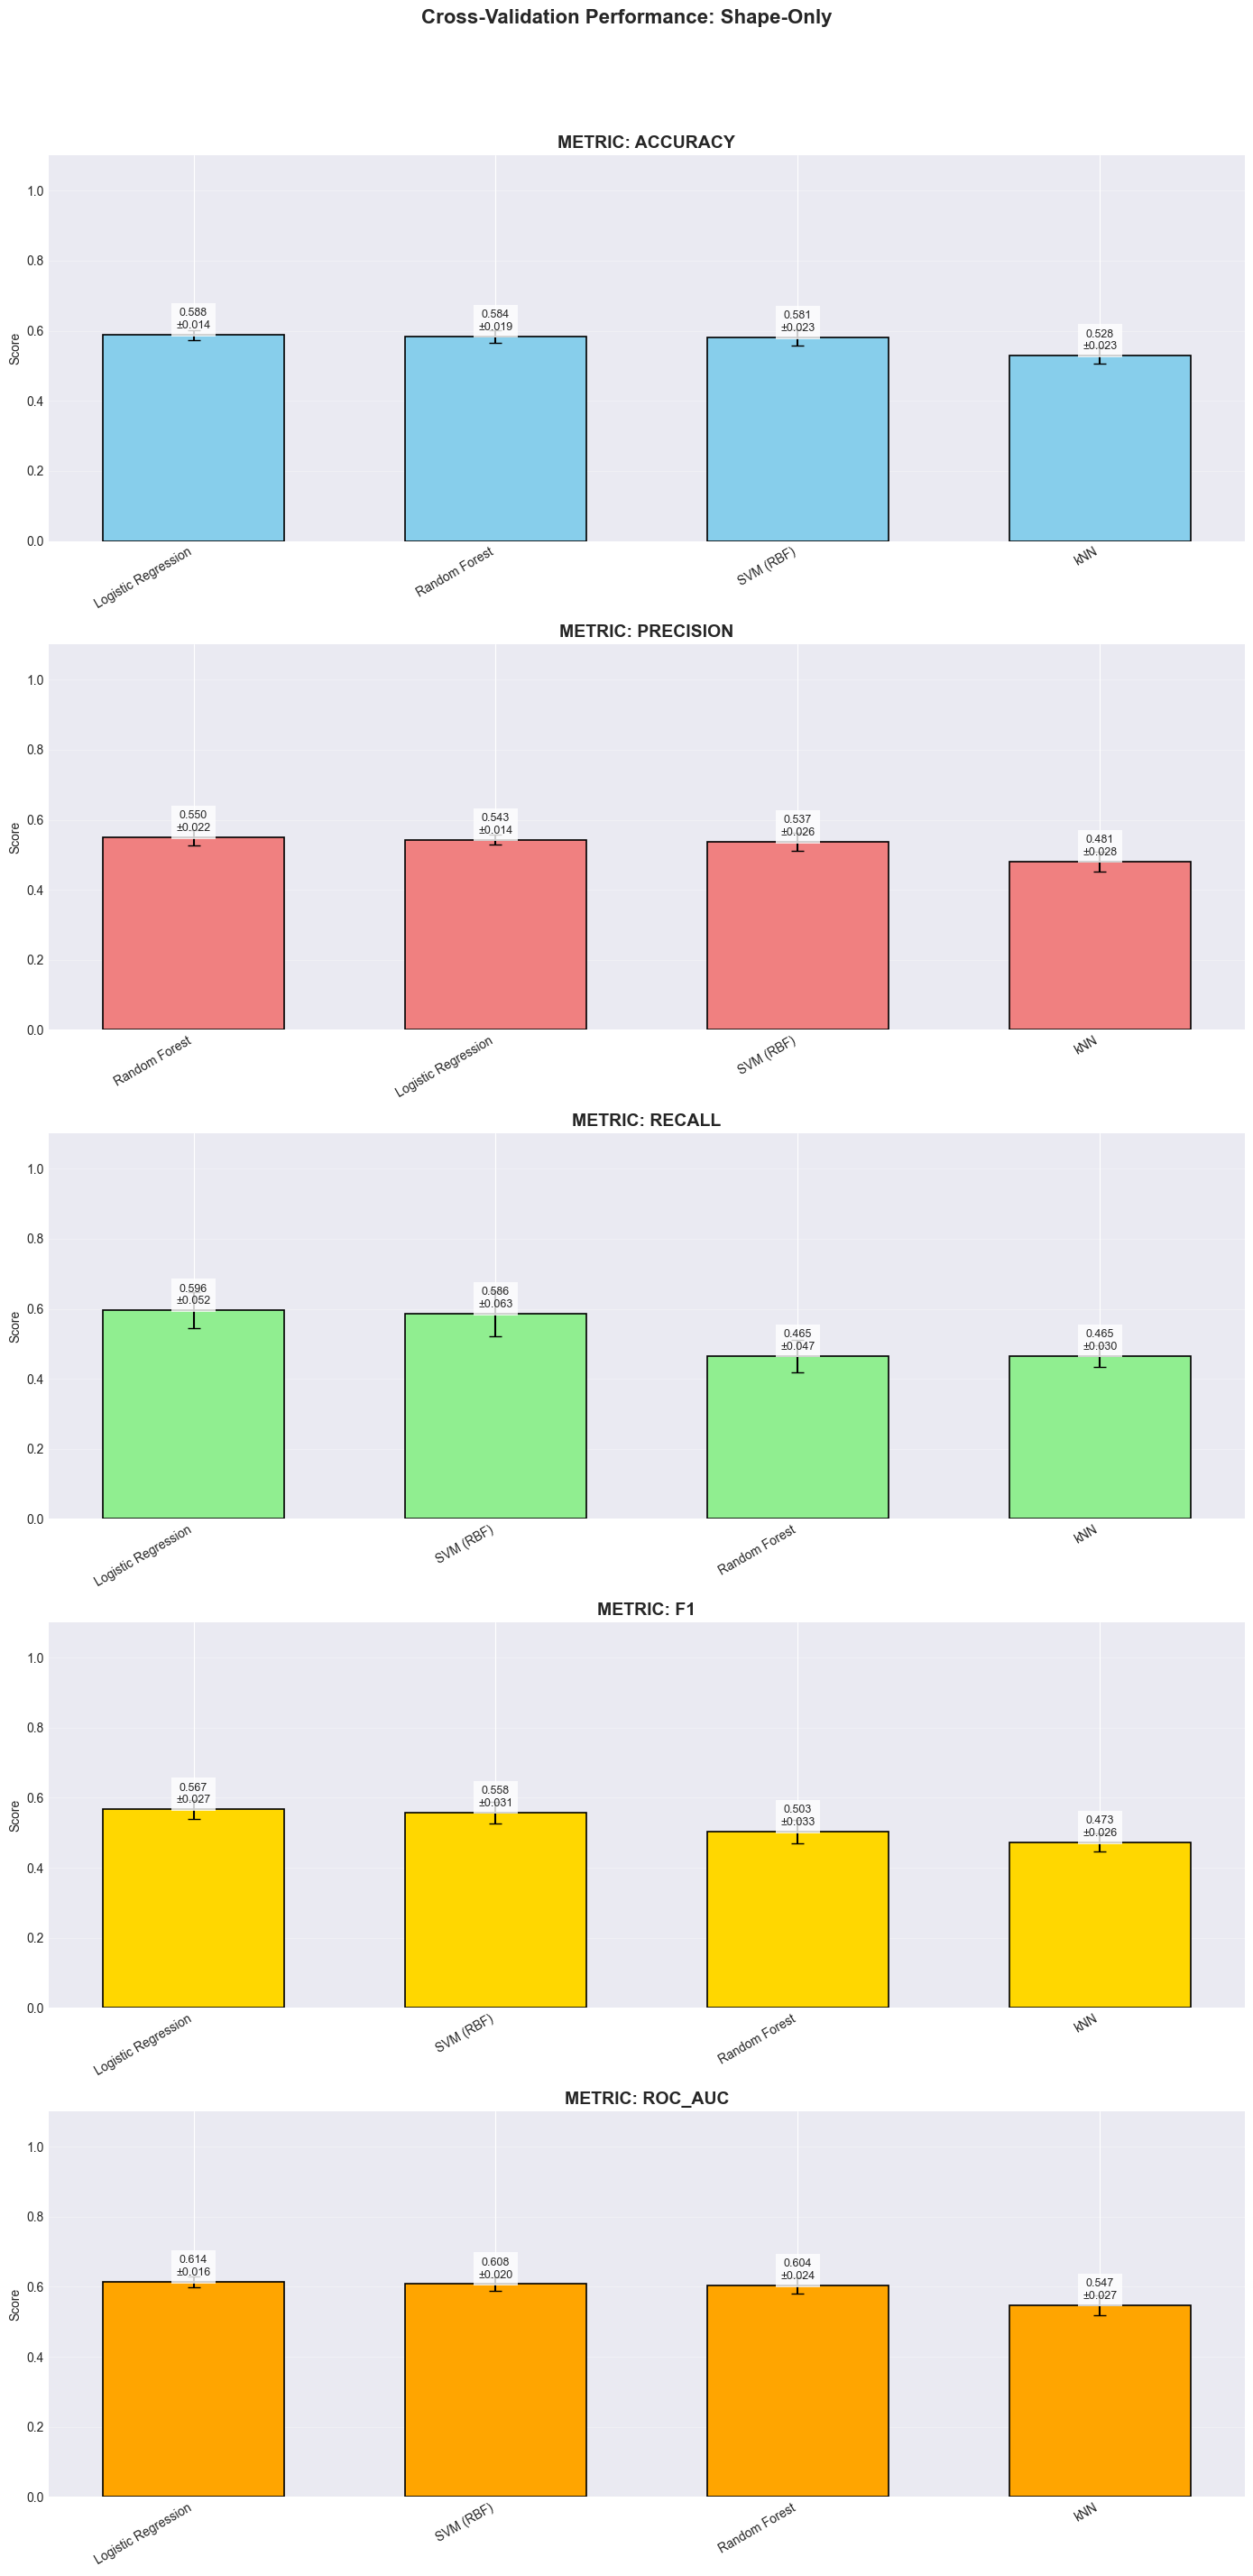


--- Generating CV Comparison Plots for: BI-RADS-Score-Only ---


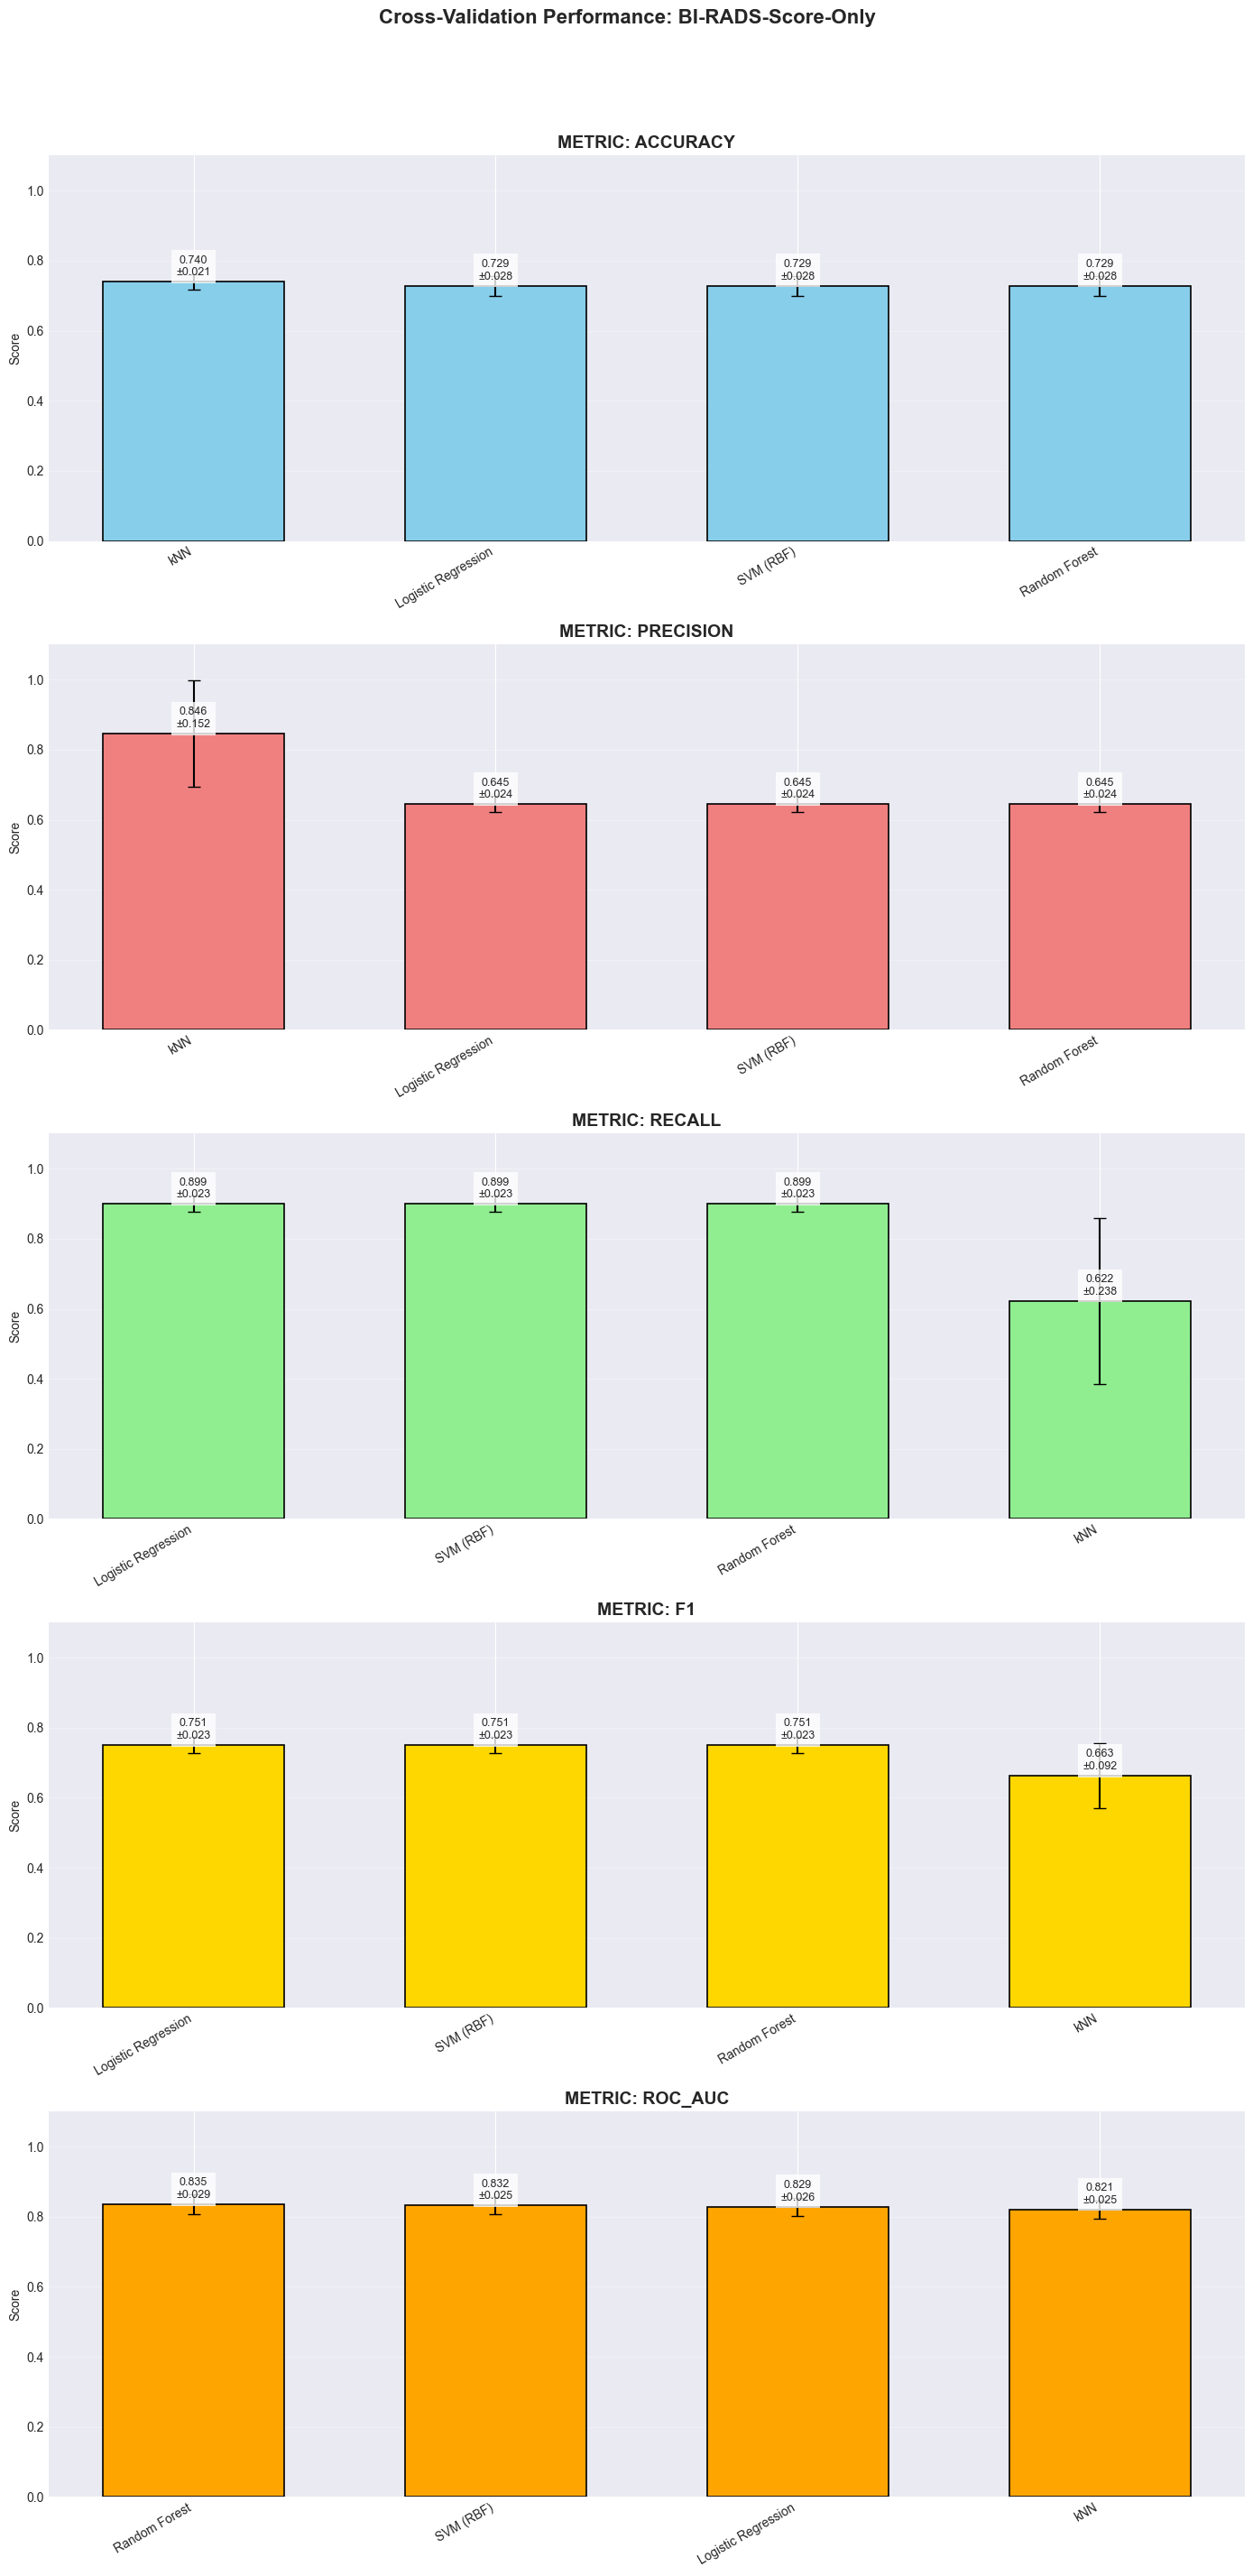


--- Generating CV Comparison Plots for: Hybrid (Shape + BI-RADS Score) ---


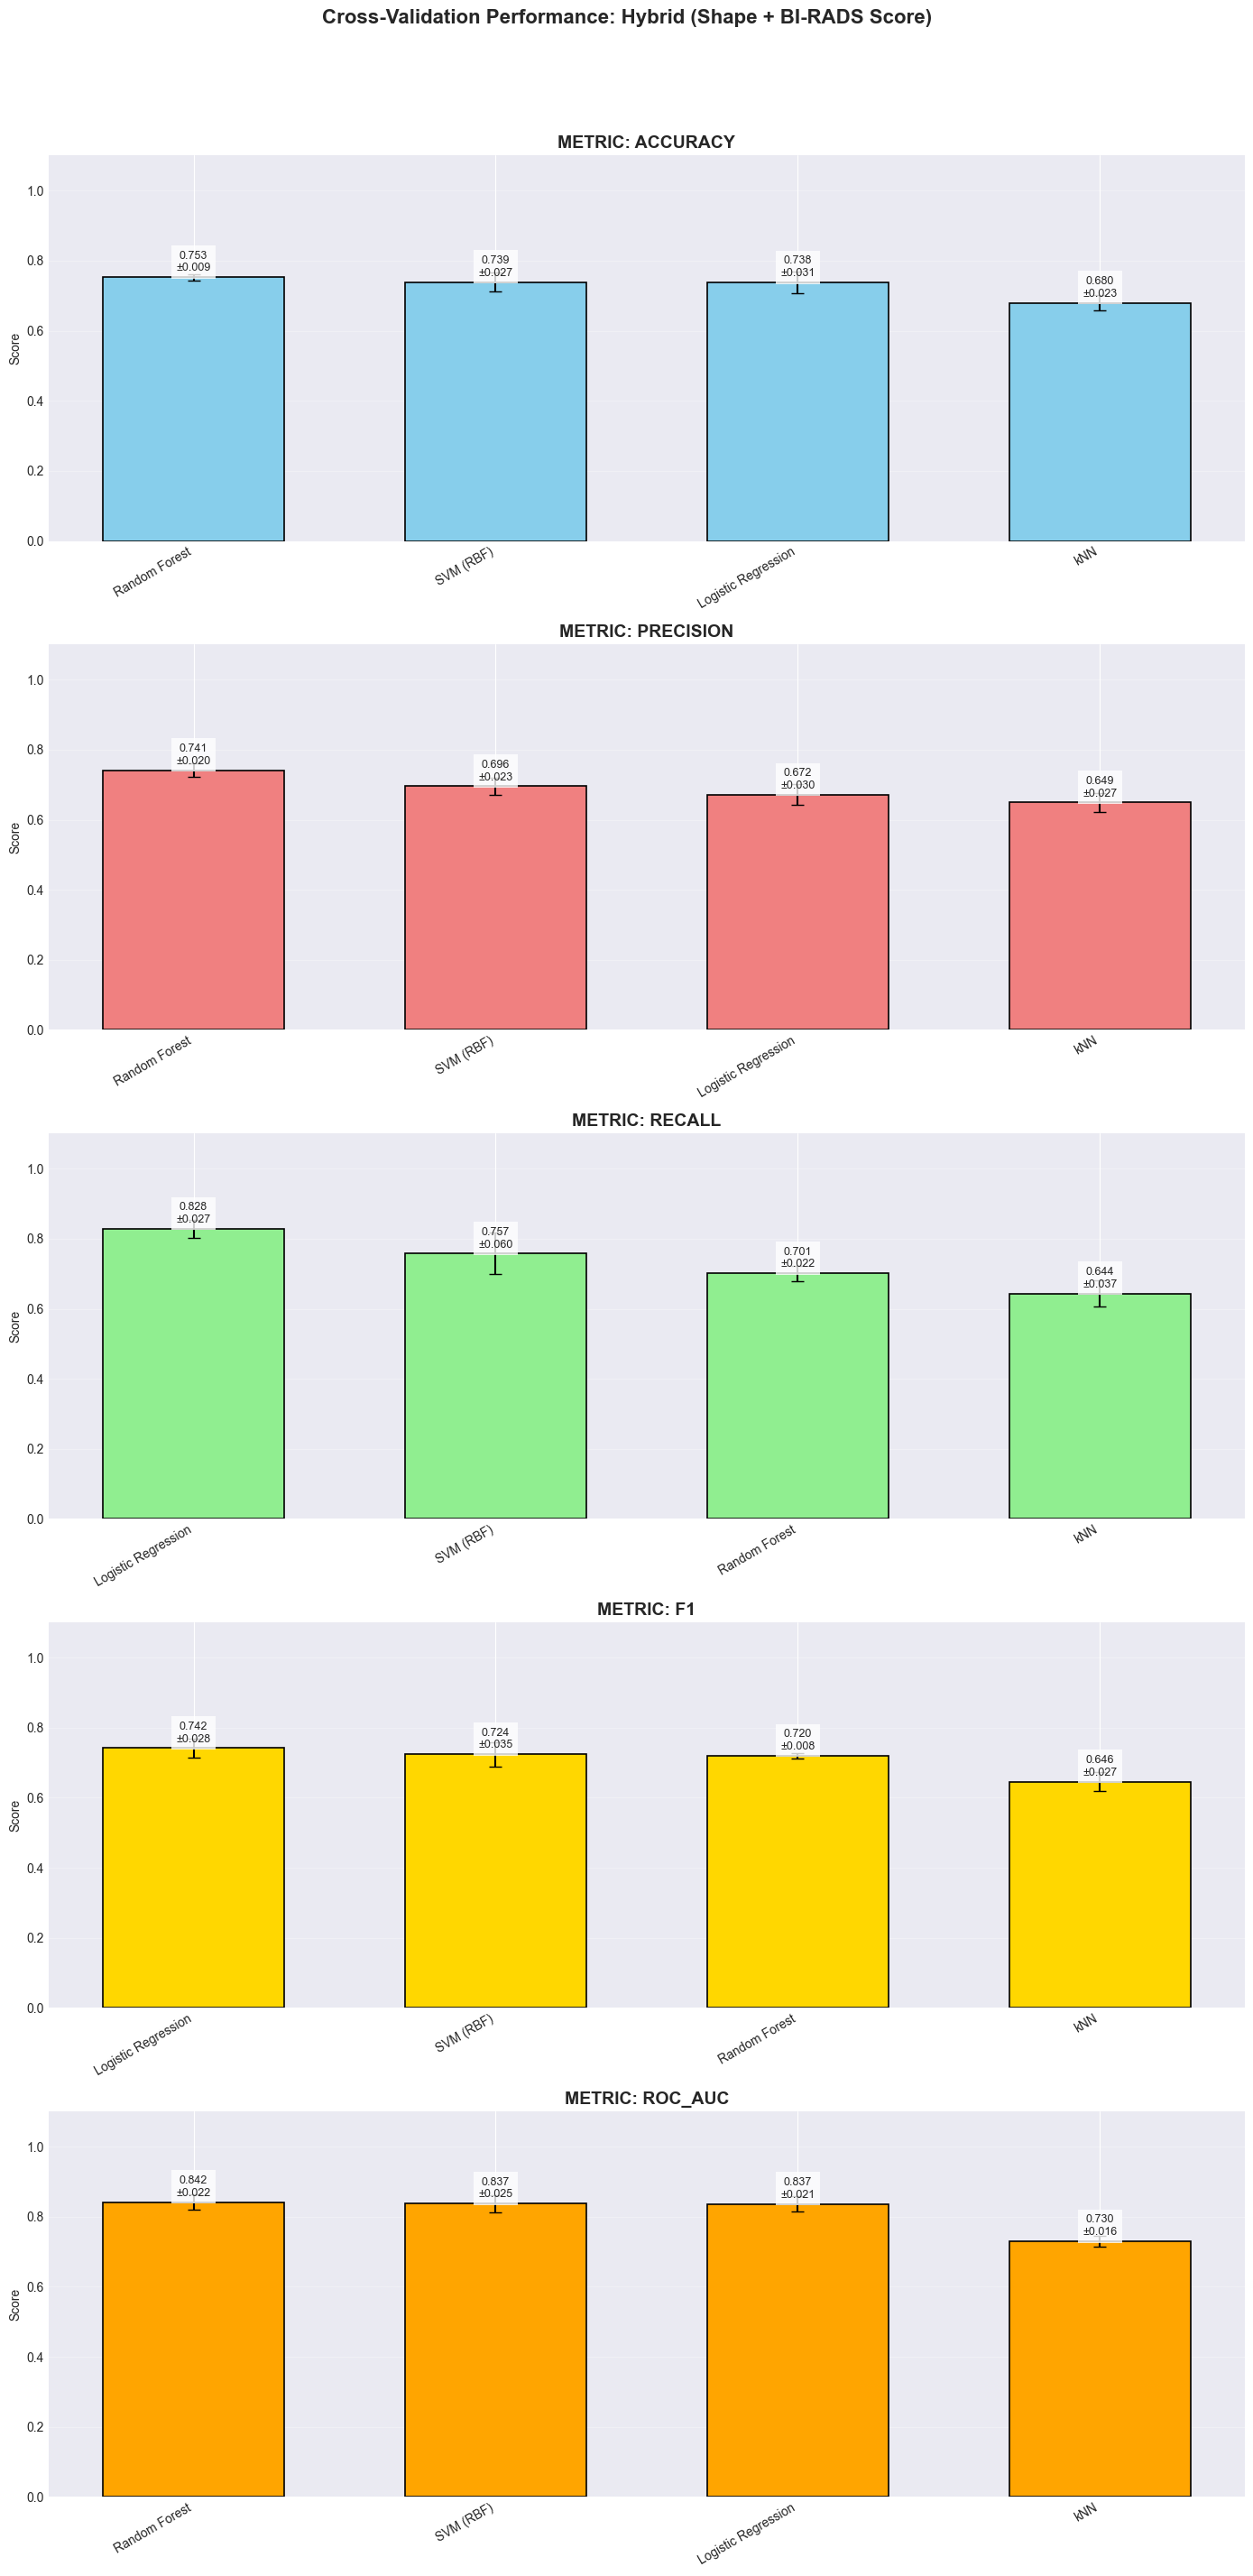

In [45]:
# CV Comparison Plots
if cv_results_data:
    COMPARISON_PLOT_PATH = "../output/cv_performance_comparison.png"
    model_eval.plot_cv_comparison(cv_results_data, scoring, COMPARISON_PLOT_PATH)

# Convert CV results to DataFrame for easier access
summary_df = pd.DataFrame(cv_results_data)

## Detailed Evaluation of the Best Models


------------------------------------------------------------
DETAILED EVALUATION: Shape-Only
------------------------------------------------------------
Best Model found via CV: Logistic Regression (roc_auc=0.6137)
Using TUNED hyperparameters.


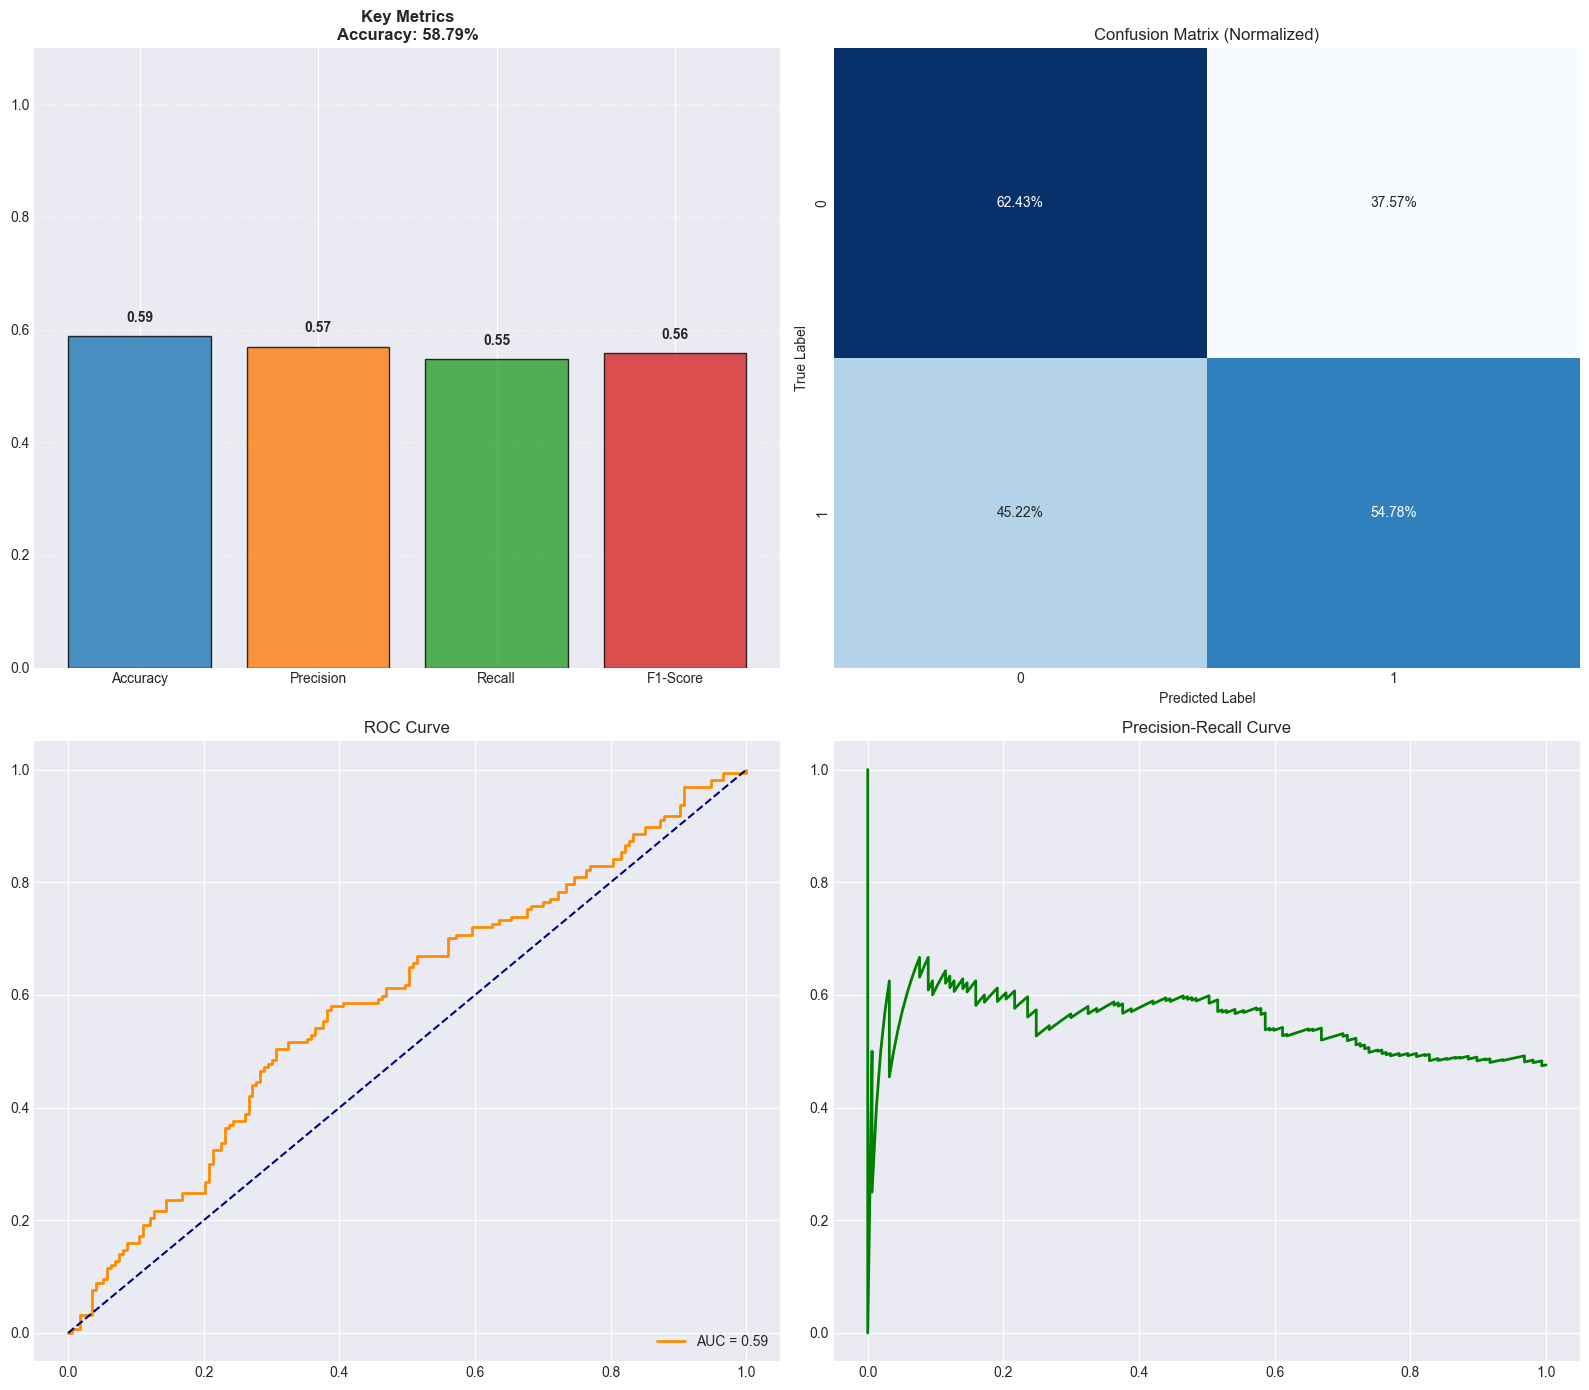

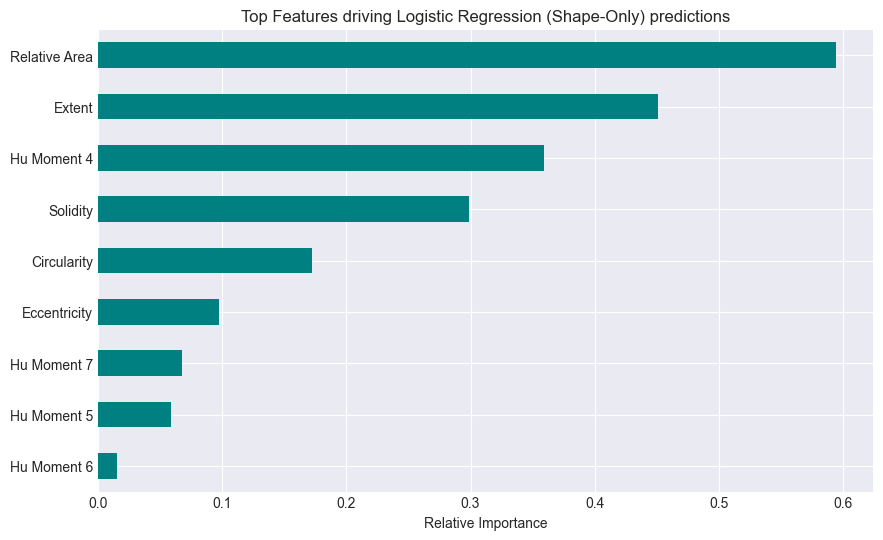

False Negatives: 71 | False Positives: 65

------------------------------------------------------------
DETAILED EVALUATION: BI-RADS-Score-Only
------------------------------------------------------------
Best Model found via CV: Random Forest (roc_auc=0.8353)
Using TUNED hyperparameters.


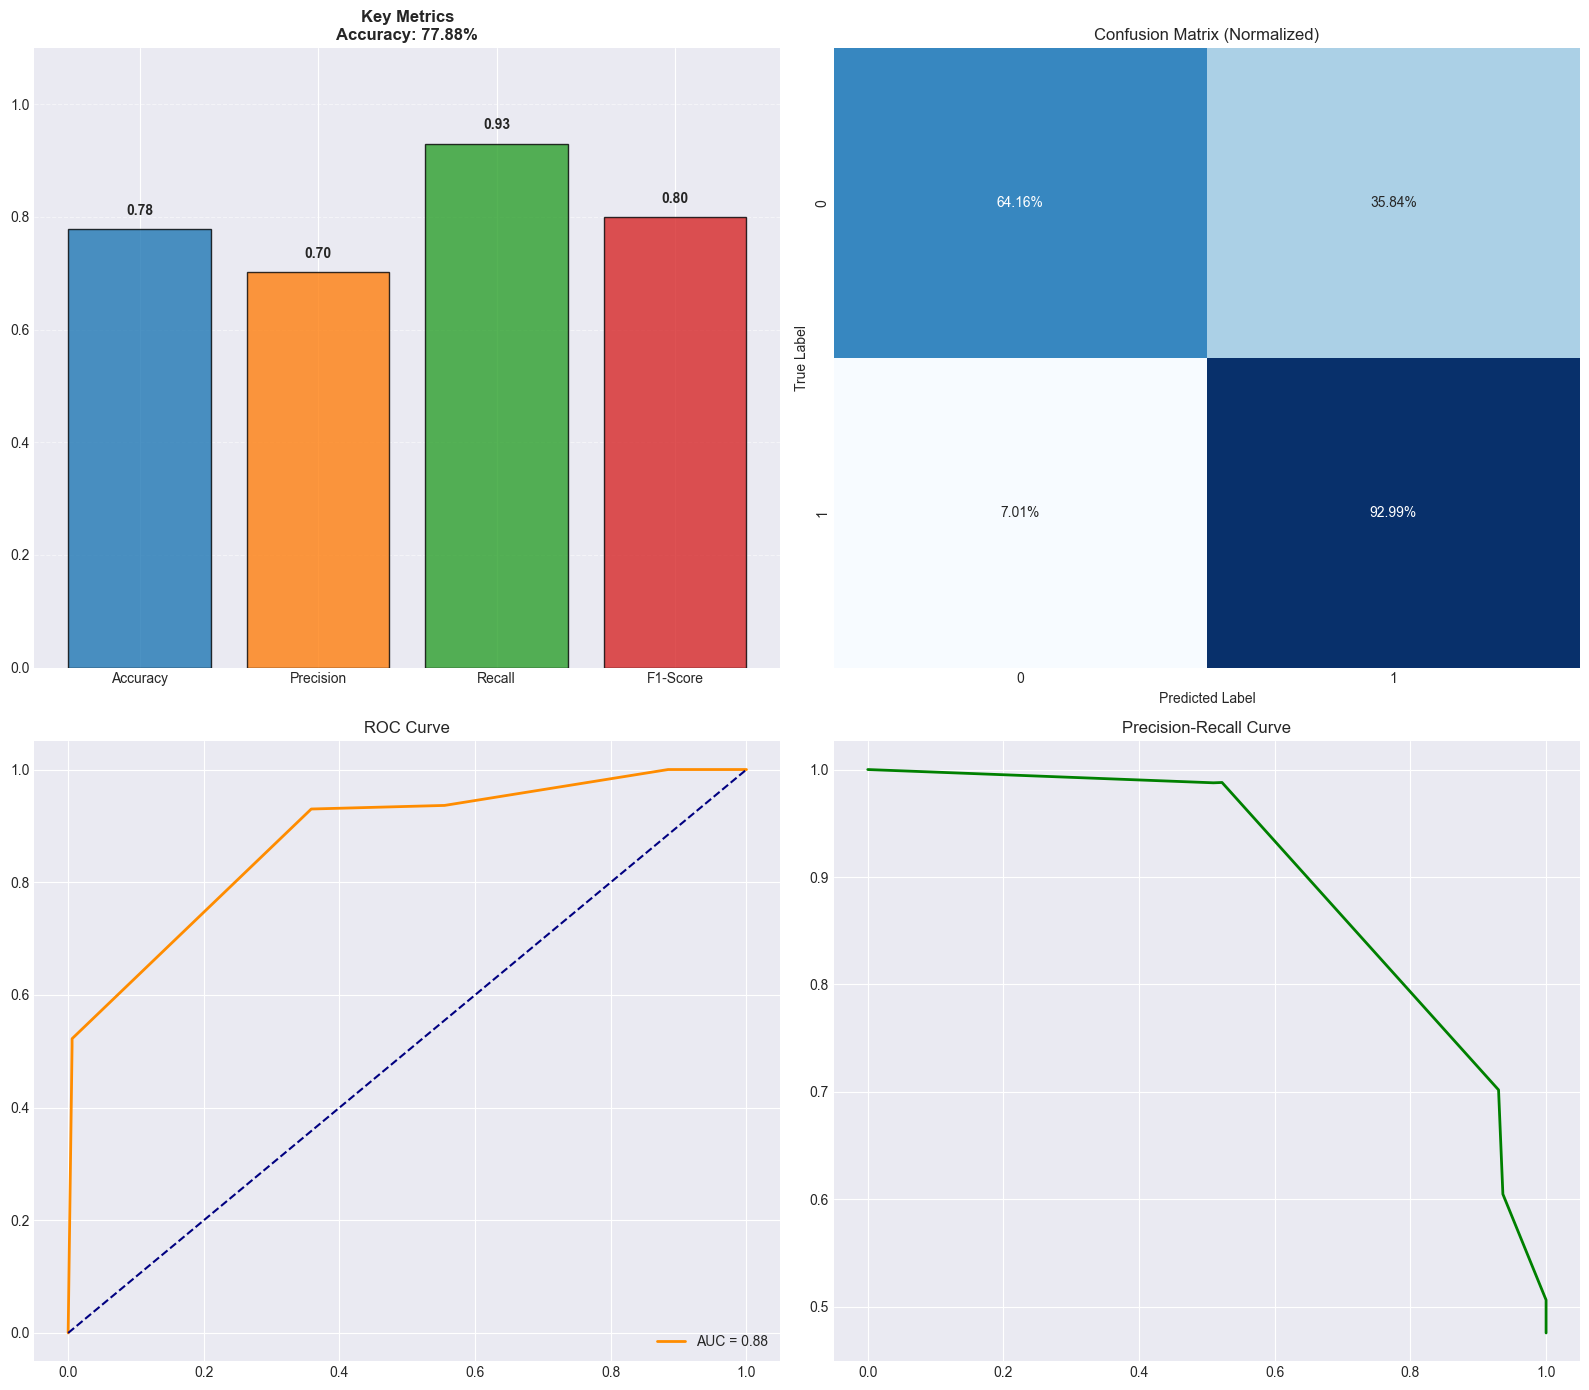

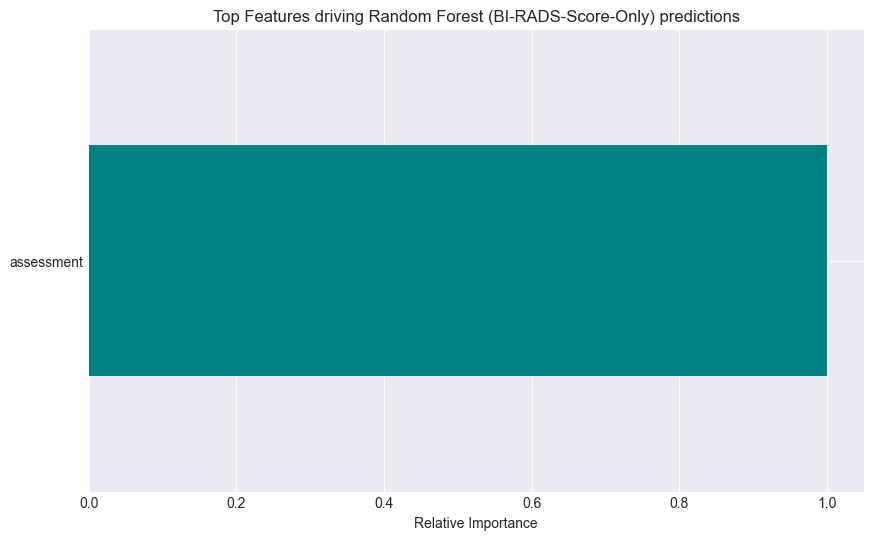

False Negatives: 11 | False Positives: 62

------------------------------------------------------------
DETAILED EVALUATION: Hybrid (Shape + BI-RADS Score)
------------------------------------------------------------
Best Model found via CV: Random Forest (roc_auc=0.8420)
Using TUNED hyperparameters.


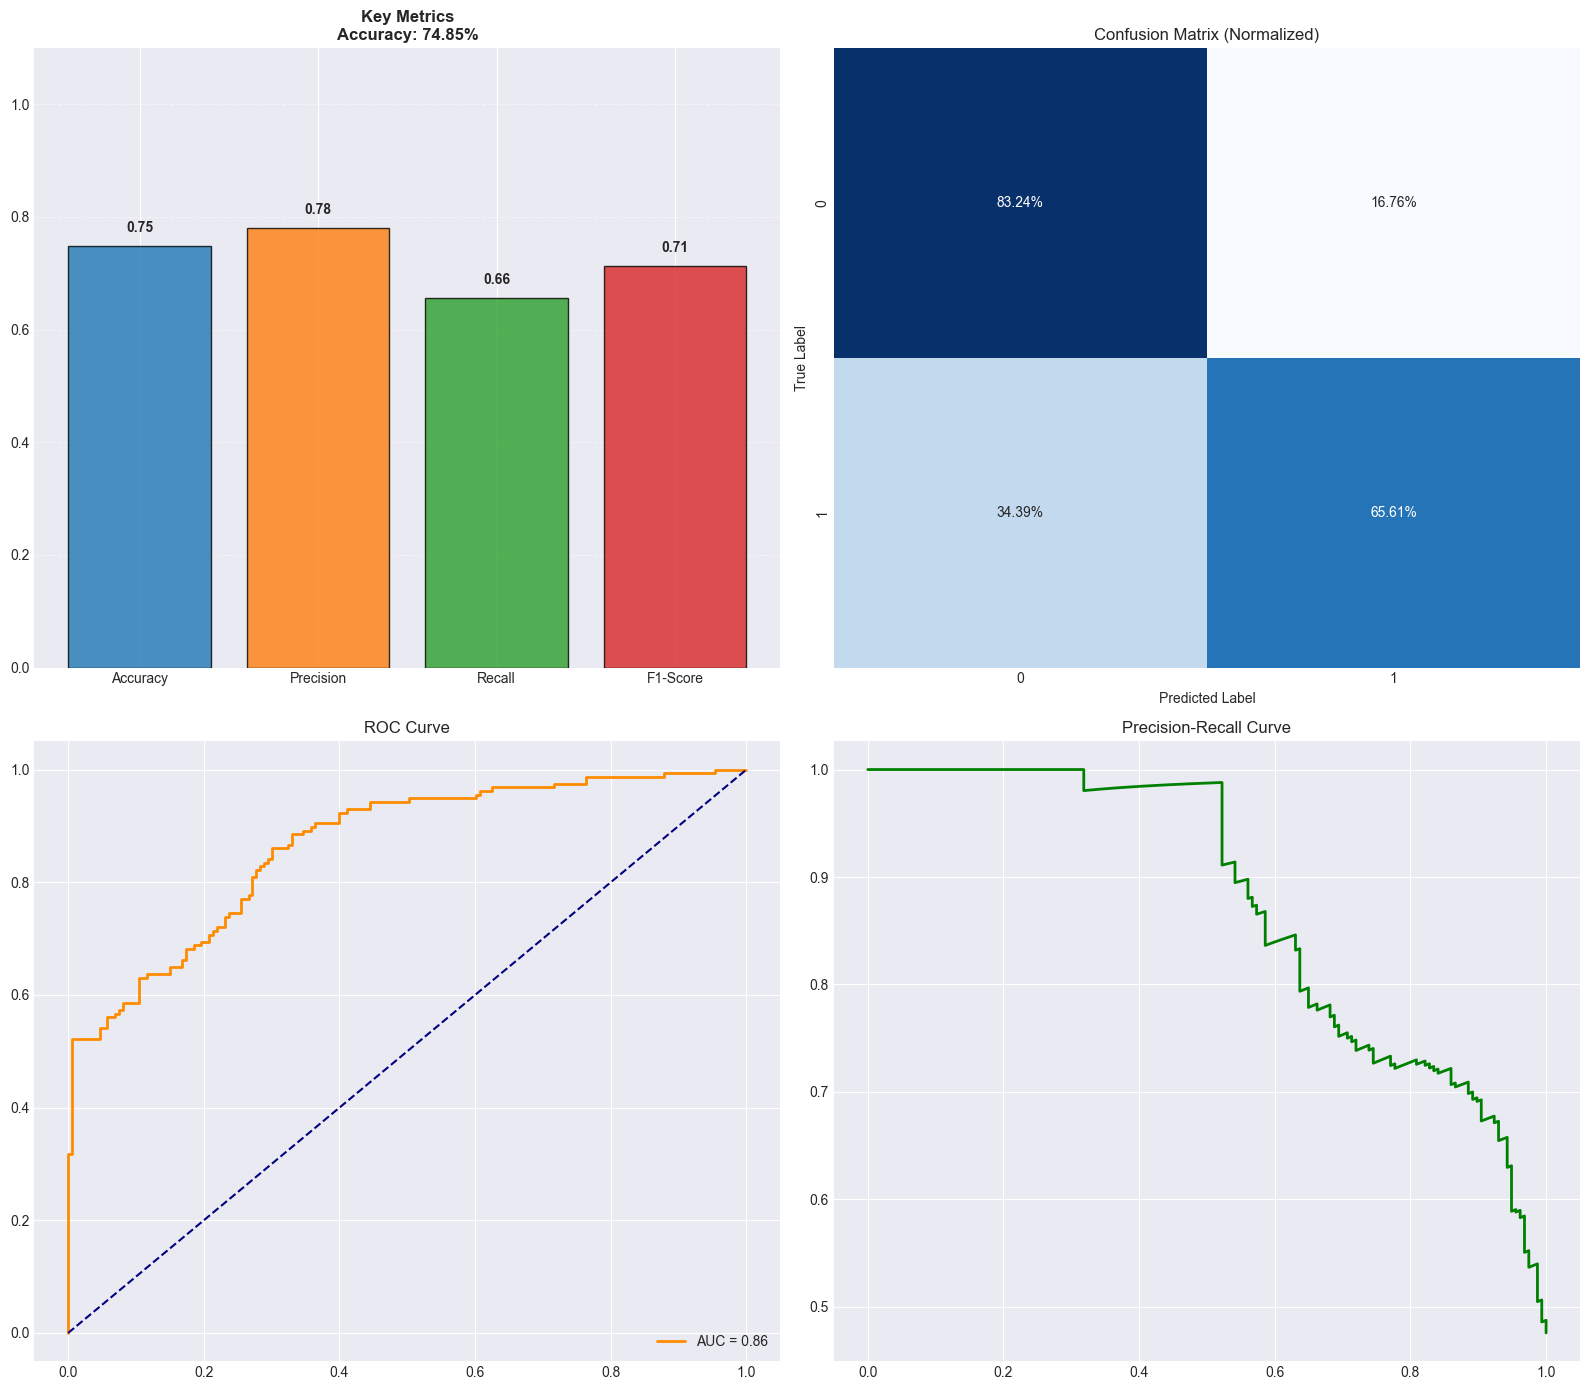

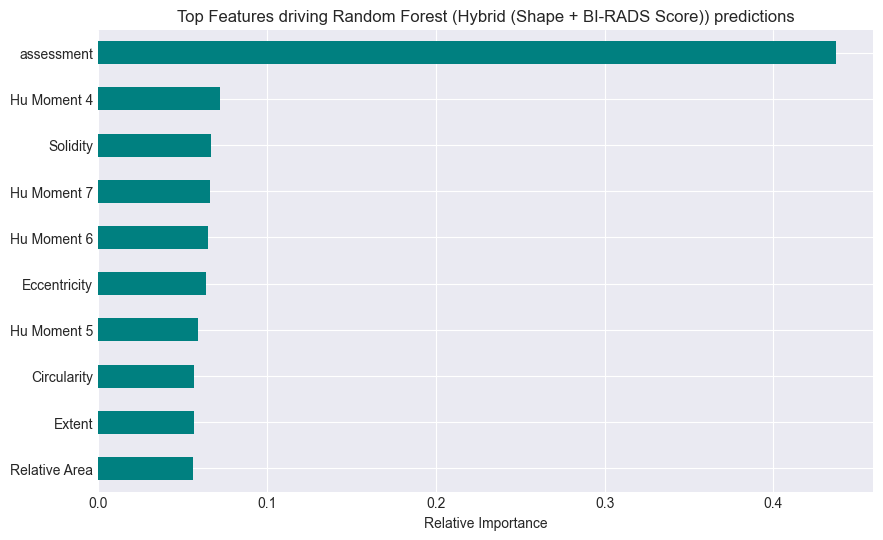

False Negatives: 54 | False Positives: 29


In [46]:
for vector_info in vectors:
    vec_name = vector_info['name']

    # Check if results exist for this vector
    if summary_df.empty or vec_name not in summary_df["Vector name: "].values:
        print(f"Skipping {vec_name} - No CV results found.")
        continue

    print(f"\n{'-' * 60}")
    print(f"DETAILED EVALUATION: {vec_name}")
    print(f"{'-' * 60}")

    # Filter results for current vector
    vec_results = summary_df[summary_df["Vector name: "] == vec_name]

    # Sort by ROC AUC descending to find the best model
    # Fallback to accuracy if roc_auc is missing for some reason
    target_metric = 'roc_auc' if 'roc_auc' in vec_results['Metric'].values else 'accuracy'

    # Get the top row
    best_row = vec_results[vec_results['Metric'] == target_metric].sort_values('Mean', ascending=False).iloc[0]

    best_model_name = best_row['Model']
    best_score = best_row['Mean']

    print(f"Best Model found via CV: {best_model_name} ({target_metric}={best_score:.4f})")

    # Select the best model instance
    best_model_instance = None

    # The winner is a Tuned Model (exists in tuning dictionary)
    if vec_name in best_models_per_vector and best_model_name in best_models_per_vector[vec_name]:
        best_model_instance = best_models_per_vector[vec_name][best_model_name]
        print(f"Using TUNED hyperparameters.")

    # The winner is a Default Model (or tuning was skipped)
    else:
        best_model_instance = models_list[best_model_name]
        print(f"Using DEFAULT hyperparameters.")

    # Retrain on full training set (just to be safe)
    best_model_instance.fit(vector_info['X_train'], vector_info['y_train'])

    # Run evaluation function
    fn_cases, fp_cases = model_eval.run_detailed_evaluation(
        model=best_model_instance,
        X_test=vector_info['X_test'],
        y_test=vector_info['y_test'],
        feature_names=vector_info['X_train'].columns,
        model_name=f"{best_model_name} ({vec_name})"
    )

    print(f"False Negatives: {len(fn_cases)} | False Positives: {len(fp_cases)}")